In [33]:
import os
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

In [34]:
from qiskit import QuantumCircuit
from qiskit_ionq import IonQProvider

In [35]:
from pennylane.templates import StronglyEntanglingLayers

In [36]:
np.random.seed(42)

def square_loss(targets, predictions):
    loss = 0
    
    for (t,p) in zip(targets, predictions):
        loss += (t-p)**2
    
    loss = 0.5 * (loss/len(targets))
    return loss

In [37]:
degree = 2
coeffs = [ 0.15 + 0.15j]*degree
coeff0 = 0.1

def target_function(x):
    func = coeff0
    for idx,coeff in enumerate(coeffs):
        exponent = complex(0, (idx + 1) * x) 
        func += coeff * np.exp(exponent) + np.conjugate(coeff) * np.exp(-exponent)
        
    return np.real(func)
        
        
    


In [38]:
n_ansatz_layers = 2
n_layers = 1
n_qubits = degree

In [39]:
dev_parallel = qml.device("default.qubit", wires = n_qubits)

def S(x):
    for w in range(n_qubits):
        qml.RY(x, wires = w)
        
#def W(theta):
#    StronglyEntanglingLayers(theta, wires = range(n_qubits))

def W(theta):
    # theta shape: (n_ansatz_layers, n_qubits, 3)
    for l in range(n_ansatz_layers):
        # single-qubit trainable rotations
        for w in range(n_qubits):
            qml.Rot(theta[l, w, 0], theta[l, w, 1], theta[l, w, 2], wires=w)

        # simple entangler
        for w in range(n_qubits - 1):
            qml.CNOT(wires=[w, w + 1])
                             
@qml.qnode(dev_parallel)
def circuit_parallel(params, x=None):
      W(params[0])
      S(x)
      W(params[1])
    
      return qml.expval(qml.PauliZ(wires = 0))
                             

In [40]:
params_parallel = 2 * np.pi * np.random.random( size = (2, n_ansatz_layers, n_qubits, 3))
print(params_parallel)

[[[[1.15255478e+00 4.89894304e+00 3.75012014e+00]
   [2.80124980e+00 6.28160922e-01 2.88554589e+00]]

  [[2.09675304e+00 8.97658691e-01 4.08965289e+00]
   [3.54444404e-01 4.53645208e+00 5.89710059e+00]]]


 [[[4.89313009e-03 6.23424909e+00 3.87975075e+00]
   [3.84313015e+00 4.43989051e-02 1.44905490e-01]]

  [[3.29725643e+00 2.51240058e+00 2.93209009e-01]
   [6.11828637e+00 1.46254547e+00 5.69297018e-01]]]]


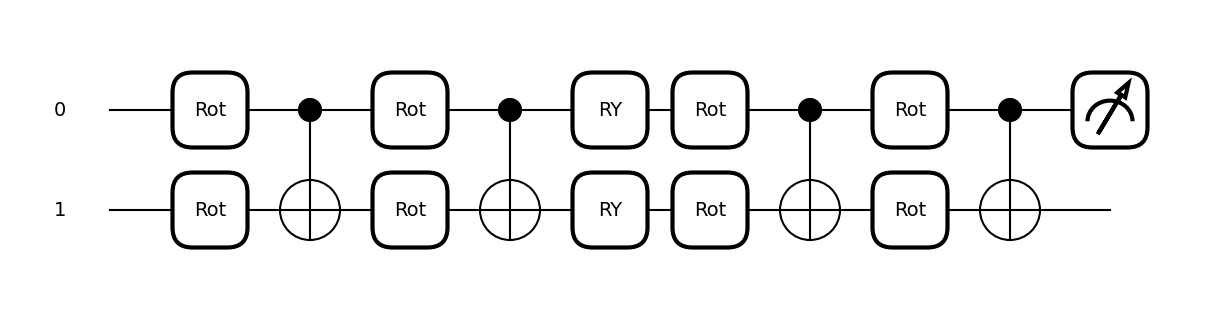

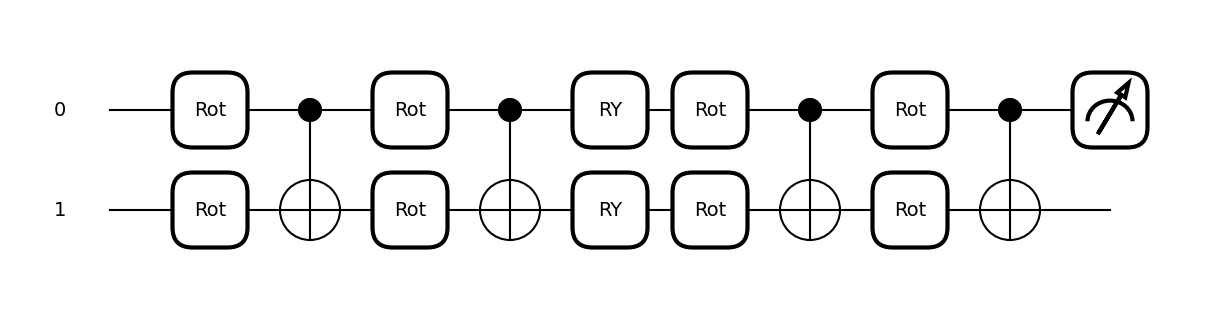

In [41]:
x = 0.5
qml.draw_mpl(circuit_parallel)(params_parallel, x=x)
fig, ax = qml.draw_mpl(circuit_parallel, level="device")(params_parallel, x=x)
plt.show()


In [42]:
def cost(params, x , y):
    predictions = [ circuit_parallel(params, x = x_) for x_ in x]
    return square_loss(y, predictions)

In [43]:
X = np.linspace(-6, 6, 70)
target_y = np.array( [target_function(x) for x in X])

cst = [cost(params_parallel, X, target_y)]
opt = qml.AdamOptimizer(0.3)
n_iter = 100
batch_size =20

In [44]:
for steps in range(n_iter):
    batch_index = np.random.randint(0, len(X), (batch_size,))
    x_batch = X[batch_index]
    y_batch = target_y[batch_index]
    
    params_parallel = opt.step(lambda p: cost(p, x_batch, y_batch), params_parallel)
    
    c = cost(params_parallel, X, target_y)
    cst.append(c)
    if ((steps + 1)%10)==0:
        print( "Cost at step {0:3}: {1}".format(steps+1, c))
        
    
    

Cost at step  10: 0.042351244982351384
Cost at step  20: 0.029861417083405208
Cost at step  30: 0.03158962417651766
Cost at step  40: 0.010535118617984498
Cost at step  50: 0.009192424780176865
Cost at step  60: 0.0016002802188132387
Cost at step  70: 0.0006998624110871911
Cost at step  80: 0.0005990799187594848
Cost at step  90: 0.00018180015981295372
Cost at step 100: 0.00015270767592359235


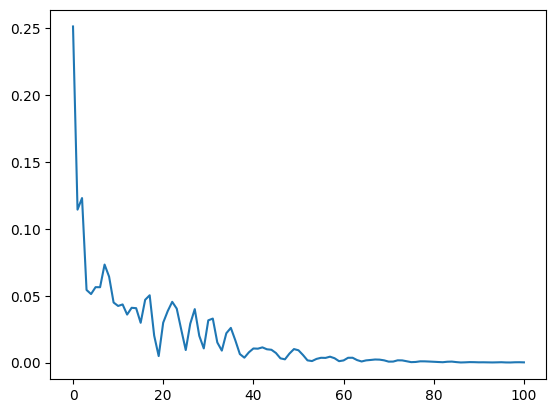

In [45]:
plt.plot(range(len(cst)), cst)

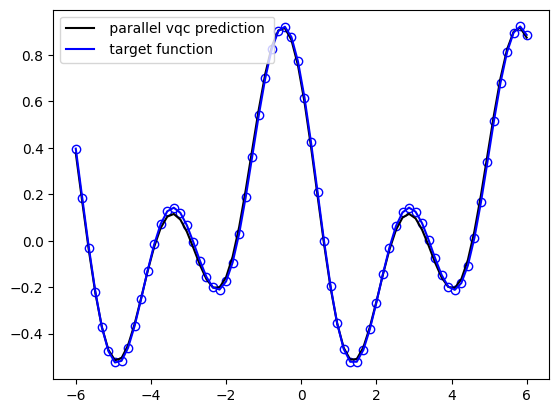

In [46]:
preds = [ circuit_parallel( params_parallel, x) for x in X]

plt.plot(X, preds, label = " parallel vqc prediction ",  c = 'black')
plt.plot(X, target_y, label = " target function ", c = "blue")
plt.scatter(X, target_y, facecolor = 'white', edgecolor = 'blue' )
plt.legend()

In [ ]:
"""
import pennylane as qml
import numpy as np

def square_loss(y, predictions):
    return np.mean((y - predictions) ** 2)

def batched_predictions(params, x_vals, dev):
    # Build one tape per x value
    tapes = [
        qml.workflow.construct_tape(circuit_parallel)(params, x=x_)
        for x_ in x_vals
    ]

    # Execute all tapes together as one batch
    results = qml.execute(
        tapes,
        dev,
        diff_method=None  # important if you're just evaluating forward passes
    )

    return np.array(results)

def cost(params, x, y):
    predictions = batched_predictions(params, x, dev_parallel)
    return square_loss(y, predictions)

X = np.linspace(-6, 6, 70)
target_y = np.array([target_function(x) for x in X])

cst = [cost(params_parallel, X, target_y)]

# This optimizer is okay only if you're NOT relying on gradients through qml.execute here
# For IonQ training, SPSA/manual updates are usually the practical route
opt = qml.AdamOptimizer(0.3)

n_iter = 100
batch_size = 20

for steps in range(n_iter):
    batch_index = np.random.randint(0, len(X), (batch_size,))
    x_batch = X[batch_index]
    y_batch = target_y[batch_index]

    params_parallel = opt.step(lambda p: cost(p, x_batch, y_batch), params_parallel)

    c = cost(params_parallel, X, target_y)
    cst.append(c)

    if (steps + 1) % 10 == 0:
        print(f"Cost at step {steps+1:3}: {c}")
        
        
        
################################        
        
        
        
import pennylane as qml
import numpy as np
from pennylane.templates import StronglyEntanglingLayers

n_qubits = 2
n_ansatz_layers = 2

dev_parallel = qml.device("default.qubit", wires=n_qubits)

def S(x):
    for w in range(n_qubits):
        qml.RY(x, wires=w)

def W(theta):
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev_parallel)
def circuit_parallel(params, x=None):
    W(params[0])
    S(x)
    W(params[1])
    return qml.expval(qml.PauliZ(0))

params_parallel = 2 * np.pi * np.random.random((2, n_ansatz_layers, n_qubits, 3))
x_vals = np.linspace(-1, 1, 5)

tapes = [qml.workflow.construct_tape(circuit_parallel)(params_parallel, x=x_) for x_ in x_vals]
results = qml.execute(tapes, dev_parallel, diff_method=None)

print(results)
"""